In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("ChurnPredictionProject") \
    .master("yarn") \
    .config("spark.submit.deployMode", "client") \
    .getOrCreate()

spark

26/02/24 12:23:00 WARN Utils: Your hostname, bhageeratha-Inspiron-15-3511 resolves to a loopback address: 127.0.1.1; using 172.18.104.168 instead (on interface wlp1s0)
26/02/24 12:23:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/24 12:23:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/24 12:23:53 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


In [4]:
df = spark.read.csv(
    "hdfs:///data/churn/telco_churn.csv",
    header=True,
    inferSchema=True
)

df.printSchema()
df.show(5)

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)

+----------+------+-------------+-------+----------+------+------------+---------

In [5]:
from pyspark.sql.functions import col, when

# Convert TotalCharges to double and handle blanks
df = df.withColumn(
    "TotalCharges",
    when(col("TotalCharges") == "", None)
    .otherwise(col("TotalCharges").cast("double"))
)

# Drop nulls created from blanks
df = df.dropna()

df.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



In [6]:
df.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5163|
|  Yes| 1869|
+-----+-----+



In [7]:
df.select("tenure", "MonthlyCharges", "TotalCharges").describe().show()

+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7032|              7032|              7032|
|   mean|32.421786120591584| 64.79820819112632|2283.3004408418697|
| stddev|24.545259709263245|30.085973884049825| 2266.771361883145|
|    min|                 1|             18.25|              18.8|
|    max|                72|            118.75|            8684.8|
+-------+------------------+------------------+------------------+



In [8]:

from pyspark.ml.feature import StringIndexer

label_indexer = StringIndexer(
    inputCol="Churn",
    outputCol="label"
)

In [9]:
categorical_cols = [
    "gender","Partner","Dependents","PhoneService",
    "MultipleLines","InternetService","OnlineSecurity",
    "OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod"
]

In [10]:
from pyspark.ml.feature import OneHotEncoder

indexers = [
    StringIndexer(inputCol=col, outputCol=col+"_index")
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(inputCol=col+"_index", outputCol=col+"_vec")
    for col in categorical_cols
]

In [11]:
from pyspark.ml.feature import VectorAssembler

numeric_cols = ["tenure","MonthlyCharges","TotalCharges","SeniorCitizen"]

assembler = VectorAssembler(
    inputCols=[col+"_vec" for col in categorical_cols] + numeric_cols,
    outputCol="features"
)

In [12]:
train, val, test = df.randomSplit([0.7, 0.15, 0.15], seed=42)

In [13]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=indexers + encoders + [label_indexer, assembler, lr])

model = pipeline.fit(train)

26/02/24 12:26:23 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


In [14]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

predictions = model.transform(test)

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(predictions)

print("AUC:", auc)

AUC: 0.8565139861329046


In [15]:
predictions.groupBy("label","prediction").count().show()

26/02/24 12:27:02 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  1.0|       1.0|  150|
|  0.0|       1.0|   76|
|  1.0|       0.0|  127|
|  0.0|       0.0|  667|
+-----+----------+-----+



In [16]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

paramGrid = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5]) \
    .build()

crossval = CrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3
)

cv_model = crossval.fit(train)

In [17]:
cv_model.write().overwrite().save("hdfs:///models/churn_model")

In [19]:
cv_model.write().overwrite().save("/home/bhageeratha/churn_model")

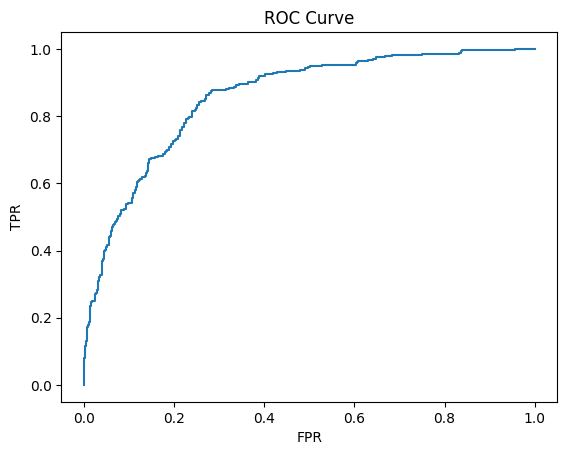

In [18]:
import matplotlib.pyplot as plt

roc = predictions.select("probability","label").collect()

# Extract probabilities
probs = [float(row.probability[1]) for row in roc]
labels = [row.label for row in roc]

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(labels, probs)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

In [20]:
df.groupBy("Churn").count().show()

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5163|
|  Yes| 1869|
+-----+-----+



In [21]:
from pyspark.sql.functions import when, col

total = df.count()
churn_yes = df.filter(col("Churn") == "Yes").count()
churn_no = df.filter(col("Churn") == "No").count()

weight_yes = total / (2 * churn_yes)
weight_no = total / (2 * churn_no)

df = df.withColumn(
    "classWeightCol",
    when(col("Churn") == "Yes", weight_yes).otherwise(weight_no)
)

In [22]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol"
)

In [24]:
from pyspark.sql.functions import when, col

total = df.count()
churn_yes = df.filter(col("Churn") == "Yes").count()
churn_no = df.filter(col("Churn") == "No").count()

weight_yes = total / (2 * churn_yes)
weight_no = total / (2 * churn_no)

df = df.withColumn(
    "classWeightCol",
    when(col("Churn") == "Yes", weight_yes).otherwise(weight_no)
)

In [25]:
train, test = df.randomSplit([0.8, 0.2], seed=42)

In [26]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeightCol"
)

In [27]:
pipeline = Pipeline(stages=indexers + encoders + [label_indexer, assembler, lr])
model = pipeline.fit(train)

In [28]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

pred = model.transform(test)

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="f1"
)

print("F1 Score:", evaluator_f1.evaluate(pred))

F1 Score: 0.7657541373964815


In [29]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,
    maxDepth=8
)

pipeline_rf = Pipeline(
    stages=indexers + encoders + [label_indexer, assembler, rf]
)

rf_model = pipeline_rf.fit(train)

rf_predictions = rf_model.transform(test)

auc_rf = evaluator.evaluate(rf_predictions)
print("Random Forest AUC:", auc_rf)

26/02/24 12:42:41 WARN DAGScheduler: Broadcasting large task binary with size 1220.5 KiB
26/02/24 12:42:42 WARN DAGScheduler: Broadcasting large task binary with size 2039.6 KiB
26/02/24 12:42:43 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/02/24 12:42:45 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


Random Forest AUC: 0.8543753859877912


In [30]:
rf_model.stages[-1].featureImportances

SparseVector(30, {0: 0.0081, 1: 0.0072, 2: 0.007, 3: 0.005, 4: 0.0078, 5: 0.008, 6: 0.0608, 7: 0.0228, 8: 0.0738, 9: 0.0139, 10: 0.0233, 11: 0.0054, 12: 0.0144, 13: 0.0061, 14: 0.09, 15: 0.0136, 16: 0.0067, 17: 0.0081, 18: 0.006, 19: 0.0088, 20: 0.1237, 21: 0.0437, 22: 0.0172, 23: 0.0382, 24: 0.0059, 25: 0.0056, 26: 0.1852, 27: 0.0705, 28: 0.1012, 29: 0.0119})

In [31]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    metricName="f1"
)

print("F1 Score:", evaluator_f1.evaluate(rf_predictions))

26/02/24 12:43:33 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


F1 Score: 0.7979382614963283


In [32]:
lr.setThreshold(0.3)

LogisticRegression_a80af491e3e7

In [33]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="label",
    maxIter=50
)

pipeline_gbt = Pipeline(
    stages=indexers + encoders + [label_indexer, assembler, gbt]
)

gbt_model = pipeline_gbt.fit(train)

gbt_predictions = gbt_model.transform(test)

print("GBT AUC:", evaluator.evaluate(gbt_predictions))

GBT AUC: 0.8383697591436253


In [34]:
df.groupBy("Contract", "Churn").count().show()

+--------------+-----+-----+
|      Contract|Churn|count|
+--------------+-----+-----+
|Month-to-month|   No| 2220|
|Month-to-month|  Yes| 1655|
|      Two year|  Yes|   48|
|      One year|   No| 1306|
|      One year|  Yes|  166|
|      Two year|   No| 1637|
+--------------+-----+-----+



In [35]:
new_customers = df.limit(5)

predictions = gbt_model.transform(new_customers)

predictions.select("customerID", "probability", "prediction").show()

+----------+--------------------+----------+
|customerID|         probability|prediction|
+----------+--------------------+----------+
|7590-VHVEG|[0.15245917209317...|       1.0|
|5575-GNVDE|[0.95069470582807...|       0.0|
|3668-QPYBK|[0.54871979222874...|       0.0|
|7795-CFOCW|[0.94995604305448...|       0.0|
|9237-HQITU|[0.44506381538187...|       1.0|
+----------+--------------------+----------+



In [36]:
gbt_model.write().overwrite().save("hdfs:///models/churn_gbt_v1")

In [37]:
gbt_model.write().overwrite().save("/home/bhageeratha/churn_gbt_v1")

In [38]:
rf_model = pipeline_rf.fit(train)

26/02/24 12:48:19 WARN DAGScheduler: Broadcasting large task binary with size 1220.5 KiB
26/02/24 12:48:19 WARN DAGScheduler: Broadcasting large task binary with size 2039.6 KiB
26/02/24 12:48:20 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
                                                                                

In [39]:
rf_stage = rf_model.stages[-1]
importances = rf_stage.featureImportances

print(importances)

(30,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29],[0.008149885301160512,0.007168309345591687,0.007041191837113903,0.004976796526752578,0.007811583206146977,0.007972716965657954,0.06079583272428952,0.022761797867425798,0.07378084628283034,0.013914536141626284,0.023345004280089735,0.005421889327328351,0.014426164350321048,0.006122456595546721,0.09003656283027191,0.013628636177096944,0.006737684146167222,0.008077048337569216,0.005979158347841022,0.008767056880598305,0.12373863723817884,0.0437075857361834,0.017245034614007997,0.03815048080261468,0.005884397720951253,0.005647078309770298,0.18516962064388187,0.07046871441793055,0.10117297777069853,0.011900315274356548])


In [40]:
feature_names = assembler.getInputCols()

importance_list = list(zip(feature_names, importances))

sorted(importance_list, key=lambda x: -x[1])[:10]

[('PaymentMethod_vec', np.float64(0.09003656283027191)),
 ('DeviceProtection_vec', np.float64(0.07378084628283034)),
 ('OnlineSecurity_vec', np.float64(0.06079583272428952)),
 ('StreamingTV_vec', np.float64(0.023345004280089735)),
 ('OnlineBackup_vec', np.float64(0.022761797867425798)),
 ('Contract_vec', np.float64(0.014426164350321048)),
 ('TechSupport_vec', np.float64(0.013914536141626284)),
 ('tenure', np.float64(0.013628636177096944)),
 ('gender_vec', np.float64(0.008149885301160512)),
 ('TotalCharges', np.float64(0.008077048337569216))]

In [41]:
lr_stage = model.stages[-1]

coefficients = lr_stage.coefficients
intercept = lr_stage.intercept

feature_names = assembler.getInputCols()

coef_list = list(zip(feature_names, coefficients))

sorted(coef_list, key=lambda x: abs(x[1]), reverse=True)[:10]

[('OnlineSecurity_vec', np.float64(0.8347861564896618)),
 ('TotalCharges', np.float64(0.4821930098991262)),
 ('PaymentMethod_vec', np.float64(0.4302716311022845)),
 ('DeviceProtection_vec', np.float64(0.4288724409298822)),
 ('OnlineBackup_vec', np.float64(-0.33373110075907114)),
 ('PaperlessBilling_vec', np.float64(0.29655544839812376)),
 ('StreamingMovies_vec', np.float64(0.2933930244388768)),
 ('Contract_vec', np.float64(0.28789655789004553)),
 ('StreamingTV_vec', np.float64(0.2859313698845245)),
 ('TechSupport_vec', np.float64(0.1791031490971878))]

In [43]:
sample_pd = test.limit(500).toPandas()

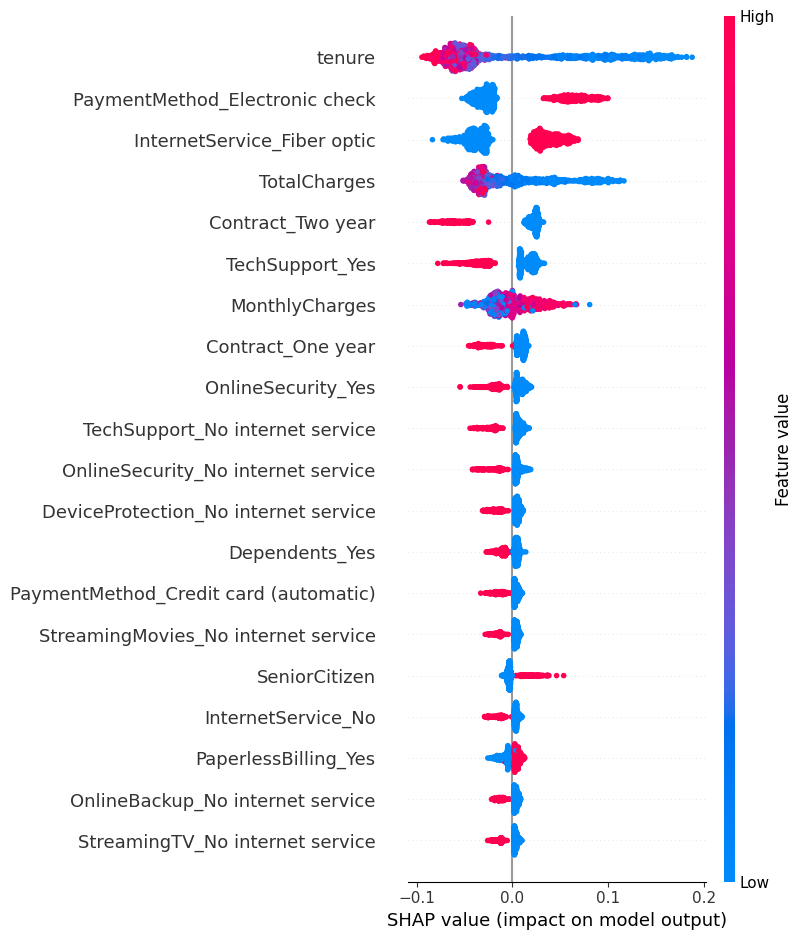

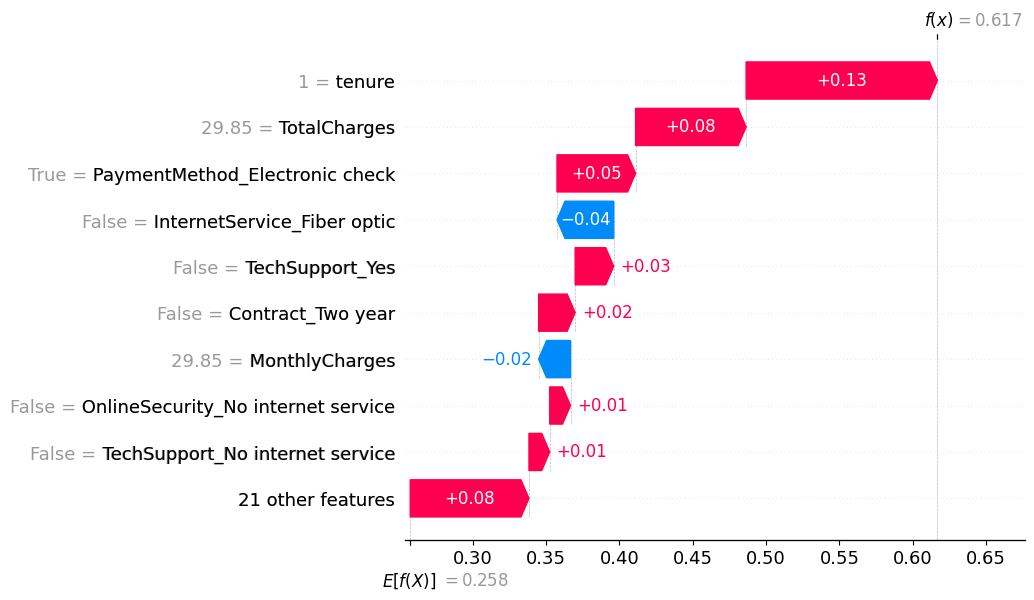

In [48]:
# ==========================================
# TELCO CHURN — SHAP INTERPRETABILITY SCRIPT
# ==========================================

# -------------------------------
# 1️⃣ Data Cleaning (Spark)
# -------------------------------

from pyspark.sql.functions import col, when

# Fix TotalCharges
df = df.withColumn(
    "TotalCharges",
    when(col("TotalCharges") == "", None)
    .otherwise(col("TotalCharges").cast("double"))
)

df = df.dropna()

# Create numeric label
df = df.withColumn(
    "label",
    when(col("Churn") == "Yes", 1).otherwise(0)
)

# -------------------------------
# 2️⃣ Define Feature Columns
# -------------------------------

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

categorical_cols = [
    "gender","Partner","Dependents","PhoneService",
    "MultipleLines","InternetService","OnlineSecurity",
    "OnlineBackup","DeviceProtection","TechSupport",
    "StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod"
]

feature_columns = numeric_cols + categorical_cols

# -------------------------------
# 3️⃣ Sample Small Dataset for SHAP
# -------------------------------

# IMPORTANT: Keep sample small (SHAP is heavy)
sample_pd = (
    df.select(feature_columns + ["label"])
      .limit(1000)
      .toPandas()
)

# -------------------------------
# 4️⃣ Pandas One-Hot Encoding
# -------------------------------

import pandas as pd

X = sample_pd[feature_columns]
y = sample_pd["label"]

X_encoded = pd.get_dummies(X, drop_first=True)

# -------------------------------
# 5️⃣ Train Sklearn RandomForest
# -------------------------------

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

rf.fit(X_encoded, y)

# -------------------------------
# 6️⃣ SHAP Explainability
# -------------------------------

import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_encoded)

# ---------------------------
# Handle SHAP version differences
# ---------------------------

if isinstance(shap_values, list):
    # Old behavior (list of arrays)
    shap_vals = shap_values[1]  # class 1 = churn
else:
    # New behavior (3D array)
    shap_vals = shap_values[:, :, 1]

# ---------------------------
# Summary Plot
# ---------------------------

shap.summary_plot(shap_vals, X_encoded)
# -------------------------------
# 8️⃣ Single Customer Explanation
# -------------------------------

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals[0],
        base_values=explainer.expected_value[1]
            if isinstance(explainer.expected_value, list)
            else explainer.expected_value[1],
        data=X_encoded.iloc[0],
        feature_names=X_encoded.columns
    )
)

In [45]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 786.0 kB/s  0:00:144.4 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 792.7 kB/s  0:00:04a 0:00:010:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 723.0 kB/s  0:01:37 eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]━━━━━━ 5/6 [shap] [numba]


In [13]:
!pip install numpy pandas scipy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 249.5 kB/s  0:01:20 eta 0:00:010:00:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 531.0 kB/s  0:00:16527.5 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 611.5 kB/s  0:00:14 eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 619.7 kB/s  0:00:077.3 kB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 607.9 kB/s  0:00:02574.5 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 797.3 kB/s  0:00:08794.5 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [matplotlib]0m 10/11 [matplotlib]it-learn]


In [2]:
!pip install pyspark

  Using cached pyspark-4.1.1-py2.py3-none-any.whl
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pyspark]━━━ 1/2 [pyspark]


In [7]:
!pip install numpy

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
